# Implementación de un ARIMA paso a paso

Pronóstico del comportamiento del índice S&P

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from statsforecast import StatsForecast
from statsforecast.models import Naive, ARIMA
import statsmodels.api as sm

sns.set_theme(style = 'darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [41]:
df = pd.read_csv('datos/S&P_500.csv',
                parse_dates=['ds'])
df

,unique_id,ds,y
0,S&P 500,2020-06-01,3055.729980
1,S&P 500,2020-06-02,3080.820068
2,S&P 500,2020-06-03,3122.870117
3,S&P 500,2020-06-04,3112.350098
4,S&P 500,2020-06-05,3193.929932
...,...,...,...
1400,S&P 500,2025-12-24,6932.049805
1401,S&P 500,2025-12-26,6929.939941
1402,S&P 500,2025-12-29,6905.740234
1403,S&P 500,2025-12-30,6896.240234


<Axes: xlabel='ds', ylabel='y'>

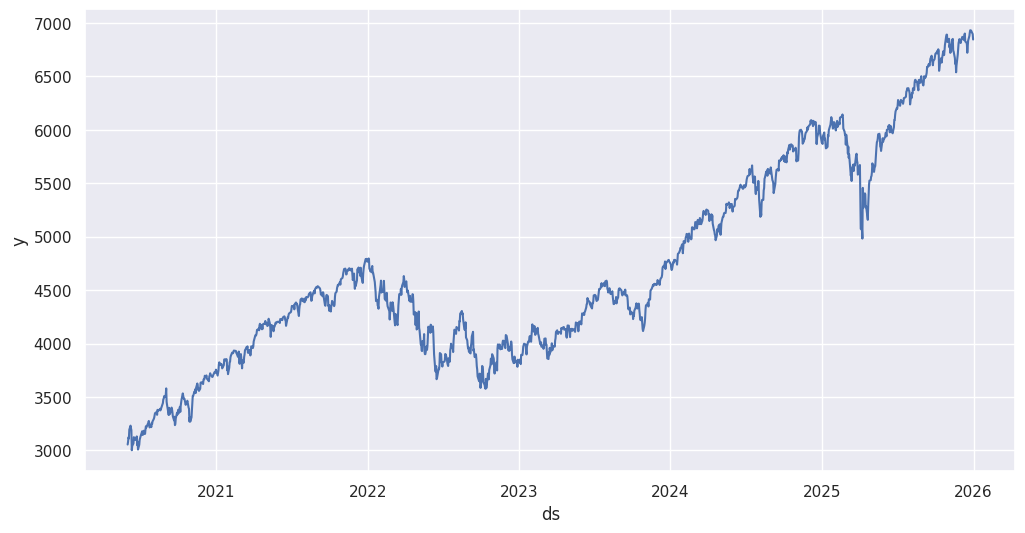

In [42]:
sns.lineplot(data = df, x = 'ds', y = 'y')

Evidentemente es una Serie no estacionaria.

Así que para este caso supondremos que el problema a resolver es **desarrollar un modelo predictivo para pronosticar el comportamiento del S&P 500 con un horizonte de 5 días**.


## Pasos involucrados en el desarrollo de un modelo predictivo (caso especial ARIMA)

1. Definir claramente el problema de predicción
2. Explorar y realizar limpieza de los datos
3. Entrenar y validar un simple modelo base (o de referencia)
4. Definir el tipo de modelo predictivo a implementar (teniendo en cuenta las características de la Serie)
5. Verificar si se cumplen los supuestos del modelo
6. Seleccionar el mejor conjunto de hiper-parámetros del modelo
7. Validar el modelo y comparar su desempeño con el del modelo base (3)
8. Generar pronósticos con el modelo seleccionado en el paso anterior


## Paso 3 Modelo base - 



En este caso (acciones en la bolsa) el método Näive es el método recomendado. En este método el siguiente valor pronosticado (o el pronóstico para una ventana "h") es simplemente la última observación:

$$y_{t+h} = y_t$$

Así que la idea es construir y evaluar el desempeño de este modelo con nuestra Serie de Tiempo y luego usar estas métricas como referencia para modelos más sofisticados.

<Axes: xlabel='ds', ylabel='y'>

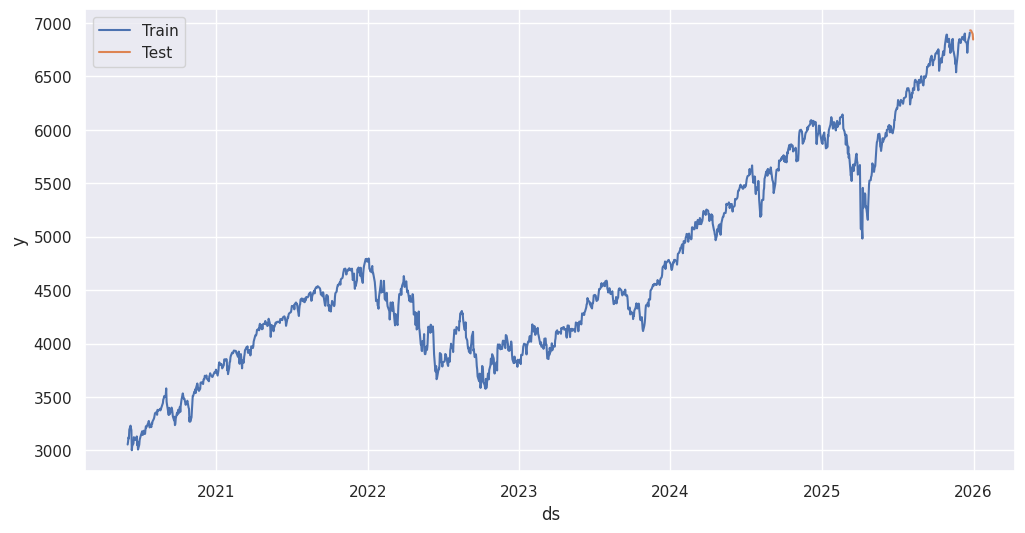

In [43]:
N = len(df)

df_train = df.iloc[ :N-5]
df_test = df.iloc[N-5: ]

sns.lineplot(data = df_train, x = 'ds', y = 'y', label = 'Train')
sns.lineplot(data = df_test, x = 'ds', y = 'y', label = 'Test')

<Axes: xlabel='ds', ylabel='y'>

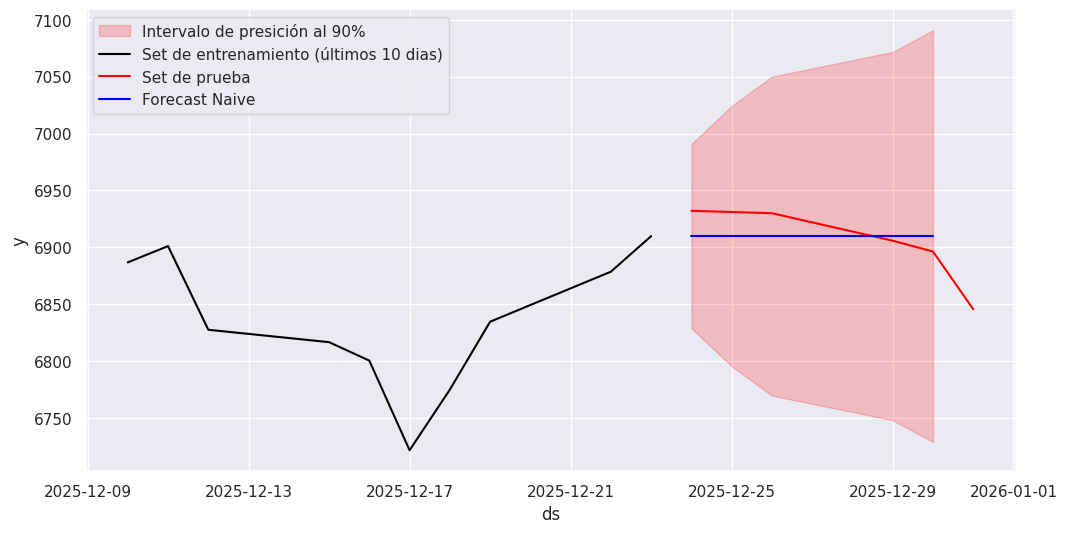

In [47]:
sf_naive = StatsForecast(models = [Naive(alias = 'Naive')], freq = 'B')
sf_naive.fit(df_train)

fc_naive = sf_naive.forecast(df = df_train, h = 5, level = [90])

fig, ax = plt.subplots()
plt.fill_between(
    x = fc_naive['ds'],
    y1 = fc_naive['Naive-lo-90'],
    y2 = fc_naive['Naive-hi-90'],
    color = 'red', 
    alpha = 0.2,
    label = 'Intervalo de presición al 90%')
sns.lineplot(df_train[-10: ], x = 'ds', y = 'y', label = 'Set de entrenamiento (últimos 10 dias)', color = 'black')
sns.lineplot(df_test, x = 'ds', y = 'y', label = 'Set de prueba', color = 'red')
sns.lineplot(fc_naive, x = 'ds', y = 'Naive', label = 'Forecast Naive', color = 'blue')


#### Medir el desempeño mediante ventanas expandibles
- Número de ventadas: 24
- Horizonte de predicción : 5
- Tamaño de paso : 10

In [52]:
cv_df_naive = sf_naive.cross_validation(
    df = df_train,
    h = 5,
    step_size = 10,
    n_windows = 24)
cv_df_naive.head(10)

,unique_id,ds,cutoff,y,Naive
0,S&P 500,2025-01-17,2025-01-16,5996.660156,5937.339844
1,S&P 500,2025-01-21,2025-01-16,6049.240234,5937.339844
2,S&P 500,2025-01-22,2025-01-16,6086.370117,5937.339844
3,S&P 500,2025-01-23,2025-01-16,6118.709961,5937.339844
4,S&P 500,2025-01-24,2025-01-16,6101.240234,5937.339844
5,S&P 500,2025-02-03,2025-01-31,5994.569824,6040.529785
6,S&P 500,2025-02-04,2025-01-31,6037.879883,6040.529785
7,S&P 500,2025-02-05,2025-01-31,6061.479980,6040.529785
8,S&P 500,2025-02-06,2025-01-31,6083.569824,6040.529785
9,S&P 500,2025-02-07,2025-01-31,6025.990234,6040.529785


In [60]:
def metricas_cv(cv_df, nombre_modelos):
    resultados = []
    for modelo in nombre_modelos:
        #Agrupar por cutoff y calcular métricas
        metricas_ventana = []
        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y']
            y_pred = ventana[modelo]

            rmse = np.sqrt(np.mean(y_true - y_pred)**2)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            mae = np.mean(np.abs(y_true - y_pred))

            metricas_ventana.append({'rmse' : rmse, 'mape' : mape, 'mae' : mae})
        
        metricas_df = pd.DataFrame(metricas_ventana)
        resultados.append({
            'Modelo' : modelo,
            'RMSE' : metricas_df['rmse'].mean(),
            'MAPE' : metricas_df['mape'].mean(),
            'MAE' : metricas_df['mae'].mean(),
            'RMSE_STD' : metricas_df['rmse'].std(),
            'MAPE_STD' : metricas_df['mape'].std(),     
            'MAE_STD' : metricas_df['mae'].std()    
        })
    return pd.DataFrame(resultados)

In [62]:
metricas_naive = metricas_cv(cv_df_naive, ['Naive'])
metricas_naive

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
0,Naive,58.84814,1.145956,68.173637,53.020342,1.044529,53.37143
